## Gaussian Process Regression of Paracetamol Saliva Concentrations

This section fits an exact Gaussian Process (GP) regression model to
paracetamol saliva concentration–time data from a single subject.
The raw JSON data are flattened into a tidy table, concentrations are
rescaled from g/L to mg/L for numerical stability, and time is used as
the sole input to the model.

A constant mean function with a Matérn (ν = 2.5) covariance kernel is
used to capture smooth, biologically plausible concentration dynamics
without imposing an explicit pharmacokinetic structure. Observation
noise is fixed to a small value to encourage near-interpolation of the
measured data.

The trained GP is evaluated on a dense time grid to visualize the
posterior mean trajectory and associated 95% uncertainty intervals.

Iter 20/100 - Loss: 7.299 | noise: 0.1000 | lengthscale: 0.559
Iter 40/100 - Loss: 4.739 | noise: 0.1000 | lengthscale: 0.477
Iter 60/100 - Loss: 4.050 | noise: 0.1000 | lengthscale: 0.422
Iter 80/100 - Loss: 3.765 | noise: 0.1000 | lengthscale: 0.407
Iter 100/100 - Loss: 3.607 | noise: 0.1000 | lengthscale: 0.391


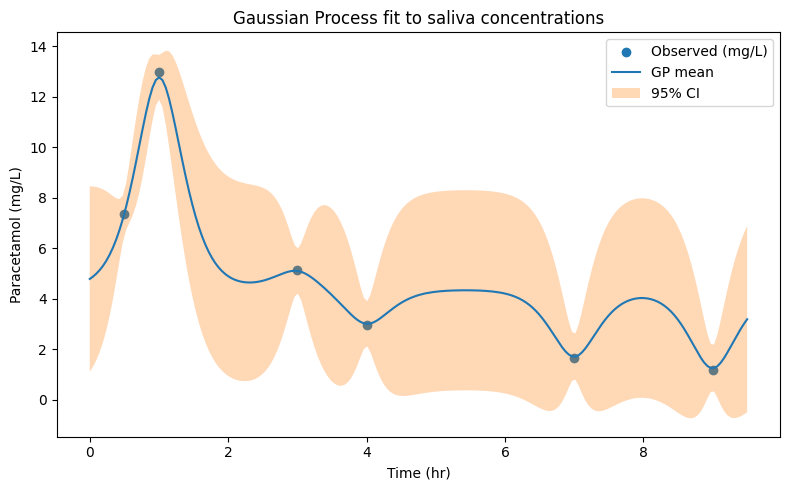

In [ ]:
import json
import torch
import gpytorch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# ---------------------------
# 1) Load & flatten JSON
# ---------------------------
with open("subject2.json") as f:
    data = json.load(f)

records = []
for row in data["array"]:
    for entry in row:
        records.append({
            "time_hr": float(entry["time"]),
            "conc_g_per_L": float(entry["value"]),
            "subject": entry["individual"]["name"],
            "dose": entry["interventions"][0]["name"],
            "tissue": entry["tissue"]["name"],
        })

df = pd.DataFrame(records).sort_values("time_hr").reset_index(drop=True)

# Optional: rescale to mg/L for better conditioning (values ~ 1–20 instead of ~0.001–0.01)
df["conc_mg_per_L"] = df["conc_g_per_L"] * 1000.0

# ---------------------------------
# 2) Prepare tensors for GPyTorch
# ---------------------------------
# Train inputs must be shape [N, 1]
x_train = torch.tensor(df["time_hr"].values, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(df["conc_mg_per_L"].values, dtype=torch.float32)

# ---------------------------------
# 3) Define an Exact GP model
# ---------------------------------
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        # RBF kernel with outputscale (amplitude) learned; add small jitter through default settings
        self.covar_module = gpytorch.kernels.ScaleKernel(
            # gpytorch.kernels.RBFKernel(lengthscale_prior=gpytorch.priors.SmoothedBoxPrior(0.1, 0.2))
            # gpytorch.kernels.RBFKernel(lengthscale_prior=gpytorch.priors.SmoothedBoxPrior(0.1, 0.5))
            gpytorch.kernels.MaternKernel(nu=2.5)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------------------------
# 4) Initialize likelihood & model
# ---------------------------------
torch.manual_seed(18)
likelihood = gpytorch.likelihoods.GaussianLikelihood()
# Fix noise to very small value for interpolation (or use FixedNoiseGaussianLikelihood)
likelihood.noise = 1e-1
likelihood.noise_covar.raw_noise.requires_grad = False  # Fix noise during training
model = ExactGPModel(x_train, y_train, likelihood)

# ---------------------------------
# 5) Train the GP
# ---------------------------------
model.train()
likelihood.train()

optimizer = torch.optim.Adam(model.parameters(), lr=0.1)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(100):
    optimizer.zero_grad()
    output = model(x_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()
    if (i + 1) % 20 == 0:
        print(f"Iter {i+1}/100 - Loss: {loss.item():.3f} | "
              f"noise: {likelihood.noise.item():.4f} | "
              f"lengthscale: {model.covar_module.base_kernel.lengthscale.item():.3f}")

# ---------------------------------
# 6) Predict on a dense grid
# ---------------------------------
model.eval()
likelihood.eval()

x_min, x_max = float(df["time_hr"].min()), float(df["time_hr"].max())
pad = 0.5
x_test = torch.linspace(max(0.0, x_min - pad), x_max + pad, 200).unsqueeze(-1)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(model(x_test))

mean = pred.mean
lower, upper = pred.confidence_region()

# ---------------------------------
# 7) Plot (in mg/L)
# ---------------------------------
plt.figure(figsize=(8,5))
plt.scatter(df["time_hr"], df["conc_mg_per_L"], label="Observed (mg/L)")
plt.plot(x_test.squeeze().numpy(), mean.numpy(), label="GP mean")
plt.fill_between(
    x_test.squeeze().numpy(),
    lower.numpy(),
    upper.numpy(),
    alpha=0.3,
    label="95% CI"
)
plt.xlabel("Time (hr)")
plt.ylabel("Paracetamol (mg/L)")
plt.title("Gaussian Process fit to saliva concentrations")
plt.legend()
plt.tight_layout()
plt.show()

## ODE-Centered Gaussian Process Model for Paracetamol Pharmacokinetics

This section fits an exact Gaussian Process (GP) regression model with a
mechanistically informed mean function based on a one-compartment oral
pharmacokinetic model (Bateman function). The mean captures the expected
absorption and elimination dynamics through learnable parameters
representing the apparent amplitude (A), absorption rate constant (ka),
and elimination rate constant (ke).

Observed saliva concentration–time data are used to train the model,
with concentrations rescaled to mg/L for numerical stability. A smooth
radial basis function (RBF) kernel models structured deviations from the
ODE-based mean, allowing the GP to flexibly account for unmodeled
biological variability while remaining anchored to pharmacokinetic
theory.

The trained model is evaluated on a dense time grid to visualize the
learned parametric ODE mean, the GP posterior mean, and corresponding
95% uncertainty intervals.

Iter 50/250 - Loss: 2.373 | noise: 0.1000 | ℓ: 0.996 | A: 28.089, ka: 0.980, ke: 0.650
Iter 100/250 - Loss: 2.246 | noise: 0.1000 | ℓ: 0.999 | A: 33.674, ka: 0.824, ke: 0.770
Iter 150/250 - Loss: 2.205 | noise: 0.1000 | ℓ: 0.999 | A: 34.723, ka: 0.799, ke: 0.791
Iter 200/250 - Loss: 2.183 | noise: 0.1000 | ℓ: 0.999 | A: 34.692, ka: 0.800, ke: 0.788
Iter 250/250 - Loss: 2.171 | noise: 0.1000 | ℓ: 0.999 | A: 34.923, ka: 0.796, ke: 0.790


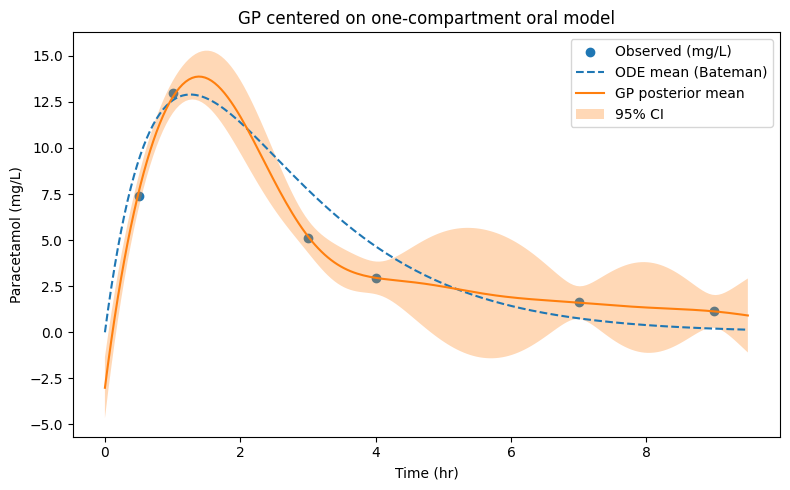

In [18]:
import json
import torch
import gpytorch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# ---------------------------
# 1) Load & flatten JSON
# ---------------------------
with open("subject2.json") as f:
    data = json.load(f)

records = []
for row in data["array"]:
    for entry in row:
        records.append({
            "time_hr": float(entry["time"]),
            "conc_g_per_L": float(entry["value"]),
            "subject": entry["individual"]["name"],
            "dose": entry["interventions"][0]["name"],
            "tissue": entry["tissue"]["name"],
        })

df = pd.DataFrame(records).sort_values("time_hr").reset_index(drop=True)

# Rescale to mg/L (helps conditioning)
df["conc_mg_per_L"] = df["conc_g_per_L"] * 1000.0

# ---------------------------------
# 2) Prepare tensors for GPyTorch
# ---------------------------------
x_train = torch.tensor(df["time_hr"].values, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(df["conc_mg_per_L"].values, dtype=torch.float32)

# ---------------------------------
# 3) Define an ODE-centered mean and GP model
# ---------------------------------
class OneCompOralMean(gpytorch.means.Mean):
    """
    Bateman function mean:
      mu(t) = A * [ka/(ka - ke)] * (exp(-ke t) - exp(-ka t))
    A absorbs F * Dose / V. ka, ke > 0 are learned.
    """
    def __init__(self, initial_A=10.0, initial_ka=1.0, initial_ke=0.2):
        super().__init__()
        # Work in log-space to keep params positive
        self.log_A  = torch.nn.Parameter(torch.log(torch.tensor(initial_A)))
        self.log_ka = torch.nn.Parameter(torch.log(torch.tensor(initial_ka)))
        self.log_ke = torch.nn.Parameter(torch.log(torch.tensor(initial_ke)))

    def forward(self, x):
        t = x.squeeze(-1)  # [N]
        A  = torch.exp(self.log_A)
        ka = torch.exp(self.log_ka)
        ke = torch.exp(self.log_ke)
        # Avoid ka ~= ke numerical issue
        denom = (ka - ke).clamp(min=1e-6)
        bateman = (ka / denom) * (torch.exp(-ke * t) - torch.exp(-ka * t))
        return bateman * A

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        # ODE-centered mean
        self.mean_module = OneCompOralMean(
            initial_A=max(y_train.max().item(), 1.0),  # rough scale
            initial_ka=1.0,  # hr^-1 (fast-ish absorption guess)
            initial_ke=0.2,  # hr^-1 (elimination guess)
        )
        # Smooth residuals around ODE with RBF
        self.covar_module = gpytorch.kernels.ScaleKernel(
            # gpytorch.kernels.RBFKernel()
            gpytorch.kernels.RBFKernel(lengthscale_prior=gpytorch.priors.SmoothedBoxPrior(1, 2))
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------------------------
# 4) Initialize likelihood & model
# ---------------------------------
torch.manual_seed(18)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

model = ExactGPModel(x_train, y_train, likelihood)
# Fix noise to very small value for interpolation (or use FixedNoiseGaussianLikelihood)
likelihood.noise = 1e-1
likelihood.noise_covar.raw_noise.requires_grad = False  # Fix noise during training
# (Optional) put weak priors to keep params reasonable
model.covar_module.base_kernel.lengthscale = 1.0
model.covar_module.outputscale = 1.0
 

# ---------------------------------
# 5) Train the GP
# ---------------------------------
model.train()
likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.parameters(), 'lr': 0.05},
], lr=0.05)
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(250):
    optimizer.zero_grad()
    output = model(x_train)
    loss = -mll(output, y_train)
    loss.backward()
    optimizer.step()
    if (i + 1) % 50 == 0:
        ka = torch.exp(model.mean_module.log_ka).item()
        ke = torch.exp(model.mean_module.log_ke).item()
        A  = torch.exp(model.mean_module.log_A).item()
        print(f"Iter {i+1}/250 - Loss: {loss.item():.3f} | "
              f"noise: {likelihood.noise.item():.4f} | "
              f"ℓ: {model.covar_module.base_kernel.lengthscale.item():.3f} | "
              f"A: {A:.3f}, ka: {ka:.3f}, ke: {ke:.3f}")

# ---------------------------------
# 6) Predict on a dense grid
# ---------------------------------
model.eval()
likelihood.eval()

x_min, x_max = float(df["time_hr"].min()), float(df["time_hr"].max())
pad = 0.5
x_test = torch.linspace(max(0.0, x_min - pad), x_max + pad, 200).unsqueeze(-1)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    pred = likelihood(model(x_test))

mean = pred.mean
lower, upper = pred.confidence_region()

# Also plot the *parametric mean* alone (without kernel)
with torch.no_grad():
    ode_mean_only = model.mean_module(x_test).detach()

# ---------------------------------
# 7) Plot (in mg/L)
# ---------------------------------
plt.figure(figsize=(8,5))
plt.scatter(df["time_hr"], df["conc_mg_per_L"], label="Observed (mg/L)")
plt.plot(x_test.squeeze().numpy(), ode_mean_only.numpy(), linestyle="--", label="ODE mean (Bateman)")
plt.plot(x_test.squeeze().numpy(), mean.numpy(), label="GP posterior mean")
plt.fill_between(
    x_test.squeeze().numpy(),
    lower.numpy(),
    upper.numpy(),
    alpha=0.3,
    label="95% CI"
)
plt.xlabel("Time (hr)")
plt.ylabel("Paracetamol (mg/L)")
plt.title("GP centered on one-compartment oral model")
plt.legend()
plt.tight_layout()
plt.show()


# Gaussian Process Coverage Experiment  
**ODE-Centered GP vs Ground Truth Bateman Model**

In [19]:
import torch
import gpytorch
import numpy as np

# ---------------------------
# 1) True Bateman model
# ---------------------------
def bateman(t, A, ka, ke):
    denom = max(ka - ke, 1e-6)
    return A * (ka/denom) * (np.exp(-ke*t) - np.exp(-ka*t))

# True parameters
A_true, ka_true, ke_true = 15.0, 1.2, 0.25
t_grid = np.linspace(0, 12, 200)
true_curve = bateman(t_grid, A_true, ka_true, ke_true)

# ---------------------------
# 2) GP model classes
# ---------------------------
class OneCompOralMean(gpytorch.means.Mean):
    def __init__(self, initial_A=10.0, initial_ka=1.0, initial_ke=0.2):
        super().__init__()
        self.log_A  = torch.nn.Parameter(torch.log(torch.tensor(initial_A)))
        self.log_ka = torch.nn.Parameter(torch.log(torch.tensor(initial_ka)))
        self.log_ke = torch.nn.Parameter(torch.log(torch.tensor(initial_ke)))

    def forward(self, x):
        t = x.squeeze(-1)
        A  = torch.exp(self.log_A)
        ka = torch.exp(self.log_ka)
        ke = torch.exp(self.log_ke)
        denom = (ka - ke).clamp(min=1e-6)
        return A * (ka/denom) * (torch.exp(-ke * t) - torch.exp(-ka * t))

class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = OneCompOralMean(
            initial_A=max(train_y.max().item(), 1.0),
            initial_ka=1.0,
            initial_ke=0.2,
        )
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ---------------------------
# 3) Coverage experiment
# ---------------------------
def run_one(seed=0, n_obs=10, noise_std=1.0):
    rng = np.random.default_rng(seed)
    # sample random timepoints
    t_obs = np.sort(rng.choice(np.arange(0, 13), size=n_obs, replace=False))
    y_obs = bateman(t_obs, A_true, ka_true, ke_true) + rng.normal(0, noise_std, size=n_obs)

    # convert to tensors
    x_train = torch.tensor(t_obs, dtype=torch.float32).unsqueeze(-1)
    y_train = torch.tensor(y_obs, dtype=torch.float32)

    # GP setup
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = ExactGPModel(x_train, y_train, likelihood)

    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    # short training loop
    for _ in range(50):
        optimizer.zero_grad()
        output = model(x_train)
        loss = -mll(output, y_train)
        loss.backward()
        optimizer.step()

    # prediction
    model.eval(); likelihood.eval()
    x_test = torch.tensor(t_grid, dtype=torch.float32).unsqueeze(-1)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(x_test))
    lower, upper = pred.confidence_region()
    lower, upper = lower.numpy(), upper.numpy()

    # coverage proportion
    covered = np.mean((true_curve >= lower) & (true_curve <= upper))
    return covered

# ---------------------------
# 4) Repeat many times
# ---------------------------
if __name__ == "__main__":
    n_trials = 1000
    coverages = [run_one(seed=i) for i in range(n_trials)]
    overall = np.mean(coverages)
    print(f"Average coverage over {n_trials} runs: {overall:.3f}")


Average coverage over 1000 runs: 0.940
